# Week 11: Clustering
## Project Tasks:
- Apply K-Means (k = 8)
- Evaluate with ARI/NMI
- Visualize clusters using PCA or t-SNE
- Optional: hierarchical clustering, DBSCAN

In [7]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")

from minilearn import StandardScaler
from minilearn import KMeans
from minilearn import PCA

from sklearn.cluster import KMeans as SKKMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [8]:
fpath = os.path.join("../data", "week5_audio.csv")

feature_df = pd.read_csv(fpath)

feature_df.head()

,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_min,mfcc_2_max,mfcc_3_mean,mfcc_3_std,mfcc_3_min,mfcc_3_max,mfcc_4_mean,mfcc_4_std,mfcc_4_min,mfcc_4_max,mfcc_5_mean,mfcc_5_std,mfcc_5_min,mfcc_5_max,mfcc_6_mean,mfcc_6_std,mfcc_6_min,mfcc_6_max,mfcc_7_mean,mfcc_7_std,mfcc_7_min,mfcc_7_max,mfcc_8_mean,mfcc_8_std,mfcc_8_min,mfcc_8_max,mfcc_9_mean,mfcc_9_std,mfcc_9_min,mfcc_9_max,mfcc_10_mean,mfcc_10_std,mfcc_10_min,mfcc_10_max,...,mel_125_max,mel_126_mean,mel_126_std,mel_126_min,mel_126_max,mel_127_mean,mel_127_std,mel_127_min,mel_127_max,mel_128_mean,mel_128_std,mel_128_min,mel_128_max,zcr_mean,zcr_std,zcr_min,zcr_max,rms_mean,rms_std,rms_min,rms_max,spectral_centroid_mean,spectral_centroid_std,spectral_centroid_min,spectral_centroid_max,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_bandwidth_min,spectral_bandwidth_max,spectral_rolloff_mean,spectral_rolloff_std,spectral_rolloff_min,spectral_rolloff_max,path,filename,emotion,intensity,actor,gender,vocal_channel
0,-726.21720,157.85083,-861.53260,-432.15480,68.54142,84.219345,-85.970474,236.70389,3.293398,20.393255,-59.614174,57.267730,12.205300,21.084995,-17.798615,106.07503,5.510278,13.634708,-37.518520,54.103424,13.667410,19.163044,-18.128150,66.360290,-2.983828,14.063683,-50.959778,30.155201,3.098029,8.619501,-21.796553,34.882523,-3.310813,10.998984,-38.751114,17.515870,-1.564384,8.348630,-26.287205,26.895653,...,9.215617e-07,1.160461e-08,2.919886e-08,0.000000e+00,2.821554e-07,5.817648e-09,5.817979e-09,0.000000e+00,3.772574e-08,5.361053e-09,4.903113e-09,0.000000e+00,2.811420e-08,0.050476,0.055781,0.0,0.278809,0.002120,0.003391,0.000000e+00,0.015828,7416.297748,4428.027505,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutral,normal,1,male,speech
1,-719.12830,159.35600,-861.44400,-417.70416,70.20157,78.612820,-14.972853,218.36372,1.168397,23.063353,-102.064600,55.451893,13.122543,18.996800,-14.094009,95.24086,7.836950,12.449026,-22.500511,53.539590,14.411290,19.218317,-17.139114,69.656890,-4.111360,14.516837,-45.138634,19.535934,4.468973,8.057330,-21.297012,31.917862,-3.539367,11.509419,-38.490250,21.244987,-3.658608,8.151206,-27.856010,10.749691,...,1.096933e-06,2.001876e-08,8.493935e-08,5.783208e-14,8.884709e-07,6.524588e-09,7.828666e-09,6.311052e-14,7.663680e-08,5.564329e-09,5.137656e-09,8.008935e-14,3.025117e-08,0.052904,0.048074,0.0,0.242676,0.002258,0.003638,1.348699e-06,0.016505,7135.571471,4196.796437,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutral,normal,1,male,speech
2,-714.99570,162.87424,-851.23380,-412.74353,69.68935,85.796005,-45.141598,229.02920,3.924564,17.979307,-44.754055,51.821846,11.924190,24.541765,-25.582266,113.43918,6.421723,10.203608,-20.508093,40.018105,11.011614,16.115140,-24.058884,61.556488,-2.878103,15.472130,-57.130900,25.875654,4.509558,9.876257,-26.122780,47.607964,-4.476109,11.993235,-43.152695,15.937588,-2.671550,8.232803,-28.637787,14.835452,...,2.650613e-05,1.852740e-07,1.275169e-06,0.000000e+00,1.443005e-05,2.746004e-08,1.501512e-07,0.000000e+00,1.417384e-06,5.536617e-09,5.639040e-09,0.000000e+00,3.369434e-08,0.046627,0.048342,0.0,0.267578,0.002707,0.004298,0.000000e+00,0.019360,7239.265648,4333.681827,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutral,normal,1,male,speech
3,-710.97530,161.77583,-847.86710,-388.34793,67.56488,78.593960,-37.103306,216.24066,5.782241,20.279503,-46.840990,63.959064,13.230727,24.528294,-31.907188,108.71458,6.190846,11.280049,-14.493299,48.574430,12.628252,16.704357,-15.486965,73.341650,-1.675170,13.141413,-44.556034,24.298128,5.657494,8.686153,-21.684810,41.637060,-4.950634,

In [9]:
m_cols = ["path", "filename", "emotion", "intensity", "actor", "gender", "vocal_channel"]
f_cols = []

for c in feature_df.columns:
    if c not in m_cols:
        f_cols.append(c)

X = feature_df[f_cols]
y = feature_df["emotion"]

In [11]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)

ml_kmeans = KMeans(n_clusters=8, max_iter=100)
ml_kmeans.fit(X_scale)
ml_labels = ml_kmeans.labels_

sk_kmeans = SKKMeans(n_clusters=8, random_state=123, n_init=10)
sk_labels = sk_kmeans.fit_predict(X_scale)

In [ ]:
cluster_results = []
cluster_results.append({"model": "MiniLearn KMeans", "k": 8, "ARI": adjusted_rand_score(y, ml_labels), "NMI": normalized_mutual_info_score(y, ml_labels)})
cluster_results.append({"model": "sklearn KMeans", "k": 8, "ARI": adjusted_rand_score(y, sk_labels), "NMI": normalized_mutual_info_score(y, sk_labels)})

cluster_df = pd.DataFrame(cluster_results)
cluster_df

,model,k,ARI,NMI
0,MiniLearn KMeans,8,0.014312,0.072559
1,sklearn KMeans,8,0.008166,0.068818


Text(0.5, 1.0, 'MiniLearn KMeans Clusters')

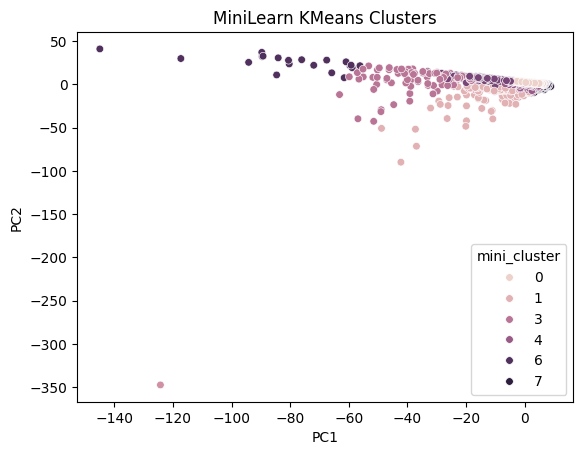

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale)

plot_df = pd.DataFrame({"PC1": X_pca[:,0], "PC2": X_pca[:,1], "emotion": y, "mini_cluster": ml_labels})

sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="mini_cluster", s=30)
plt.title("MiniLearn KMeans Clusters")


Text(0.5, 1.0, 'Emotion Labels')

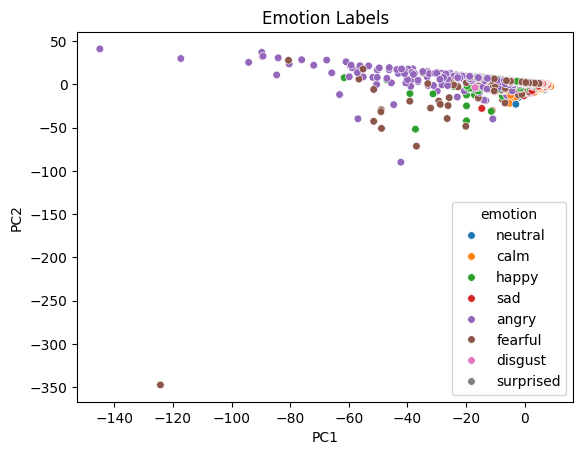

In [17]:
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="emotion", s=30)
plt.title("Emotion Labels")